# Day 8: Gates as matrices

**Tue, Oct 13 · Intro · about 30 minutes**

A quantum gate is a unitary matrix, and applying it is a matrix-vector product (Day 3). This is a first look; Module 1–2 go deeper.

**By the end of this notebook you can:**
- Apply X, Z and H to |0⟩ and |1⟩
- Check that a gate is unitary (U†U = I)
- Chain gates and read the order correctly

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
plus = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)

X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

## 1. Three gates to know
- **X** (NOT): swaps |0⟩ ↔ |1⟩
- **Z** (phase flip): leaves |0⟩ alone, sends |1⟩ → −|1⟩
- **H** (Hadamard): |0⟩ → |+⟩ and |1⟩ → |−⟩, creating superposition

In [2]:
for gname, G in [("X", X), ("Z", Z), ("H", H)]:
    print(f"{gname}|0> = {G @ ket0},   {gname}|1> = {G @ ket1}")

X|0> = [0.+0.j 1.+0.j],   X|1> = [1.+0.j 0.+0.j]
Z|0> = [1.+0.j 0.+0.j],   Z|1> = [ 0.+0.j -1.+0.j]
H|0> = [0.7071+0.j 0.7071+0.j],   H|1> = [ 0.7071+0.j -0.7071+0.j]


### What each gate does to the |0⟩ and |1⟩ arrows

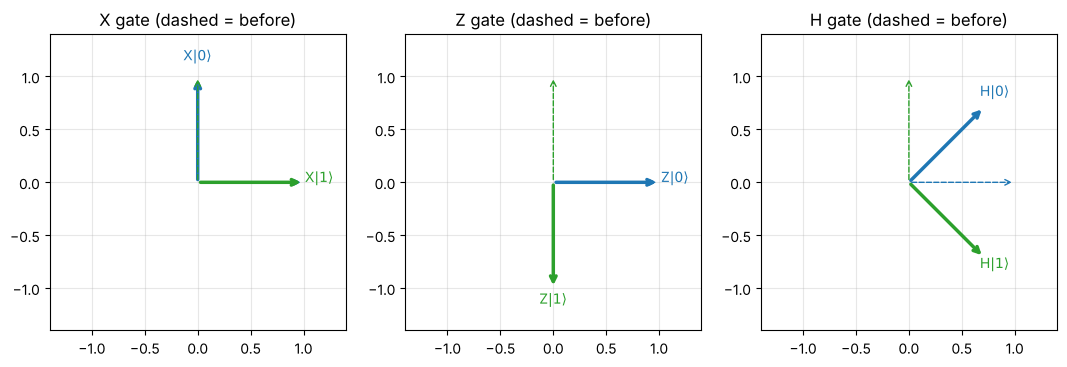

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (gname, G) in zip(axes, [("X", X), ("Z", Z), ("H", H)]):
    for vec, lab, c in [(ket0, "|0>", "C0"), (ket1, "|1>", "C2")]:
        out = (G @ vec).real
        ax.annotate("", xy=vec.real, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=1, ls="--"))
        ax.annotate("", xy=out, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2.5))
        ax.text(out[0] * 1.15, out[1] * 1.15, gname + tex(lab), color=c, ha="center")
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4); ax.set_aspect("equal"); ax.set_title(f"{gname} gate (dashed = before)")
plt.show()

## 2. Why gates must be unitary
A gate must keep the state normalised (probabilities still sum to 1). The matrices that preserve length are exactly the **unitary** ones: **U†U = I**.
A bonus: every unitary can be undone by applying U†, so quantum gates are reversible.

In [4]:
for gname, G in [("X", X), ("Z", Z), ("H", H)]:
    print(gname, "unitary?", np.allclose(G.conj().T @ G, np.eye(2)))
NOT_UNITARY = np.array([[1, 1], [0, 1]])
print("[[1,1],[0,1]] unitary?", np.allclose(NOT_UNITARY.T @ NOT_UNITARY, np.eye(2)))

X unitary? True
Z unitary? True
H unitary? True
[[1,1],[0,1]] unitary? False


## 3. Chaining gates
A circuit `|0⟩ → H → Z → H` is the matrix product **H·Z·H** applied to |0⟩. Read the circuit left to right, but write the product right to left.

In [5]:
state = H @ Z @ H @ ket0
print("H Z H |0> =", np.round(state, 6), "  (that's |1>: HZH acts like X)")
print("HZH == X ?", np.allclose(H @ Z @ H, X))

H Z H |0> = [-0.+0.j  1.+0.j]   (that's |1>: HZH acts like X)
HZH == X ? True


## Exercises
**E1.** Compute H|0⟩ by hand for H = (1/√2)[[1, 1], [1, −1]].

**E2.** Verify H·H = I. What does applying H twice do?

In [6]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** H(1, 0) = (1/√2)(1·1 + 1·0, 1·1 + (−1)·0) = (1/√2, 1/√2) = **|+⟩**.

**E2.** H·H = ½[[1+1, 1−1], [1−1, 1+1]] = I. Applying H twice returns the original state.

</details>

In [7]:
assert np.allclose(H @ ket0, plus) and np.allclose(H @ H, np.eye(2))
print("All Day 8 checks passed.")

All Day 8 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 9 (intro): Two qubits and tensor products

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*